# 8.5 大语言模型概述

> **课时**：1课时 | **难度**：⭐⭐⭐⭐ | **竞赛重要度**：⭐⭐⭐⭐⭐

## 📚 学习目标

1. 理解大语言模型（LLM）的核心思想
2. 掌握预训练-微调范式
3. 了解 Transformer 架构的核心组件
4. 对比 GPT、BERT、T5 等主流模型
5. 了解提示工程（Prompt Engineering）基础
6. 总结竞赛相关考点

---

## 1. 大语言模型（LLM）的核心思想

### 1.1 什么是大语言模型？

大语言模型（Large Language Model, LLM）是基于海量文本数据训练的深度学习模型，能够理解、生成和推理自然语言。

**核心能力**：

| 能力 | 说明 | 示例 |
|------|------|------|
| **文本生成** | 根据上下文生成连贯文本 | 写文章、写代码 |
| **问答** | 理解问题并给出答案 | 知识问答 |
| **翻译** | 多语言翻译 | 中英文互译 |
| **推理** | 逻辑推理与数学计算 | 解数学题 |
| **代码生成** | 根据描述生成代码 | Python/SQL 代码 |
| **摘要** | 提取关键信息生成摘要 | 文章摘要 |

### 1.2 LLM 的本质：下一个词预测

LLM 的核心任务可以简化为：

$$P(w_t | w_1, w_2, \ldots, w_{t-1})$$

即**根据前面的文本预测下一个词的概率分布**。

> **自回归生成**：模型逐个词生成文本，每次将已生成的词作为输入，预测下一个词。

### 1.3 规模的力量

LLM 之所以"大"，体现在：

| 维度 | 典型规模 |
|------|---------|
| 参数量 | 数十亿到数千亿（GPT-4 ~ 1.8T, LLaMA-7B~65B） |
| 训练数据 | 数万亿 tokens |
| 训练算力 | 数千 GPU/TPU 训练数月 |
| 上下文长度 | 数千到数十万 tokens |

> **Scaling Law**（Kaplan et al., 2020）：模型性能与参数量、数据量、计算量呈幂律关系。

---

## 2. 预训练-微调范式（Pre-training & Fine-tuning）

### 2.1 两阶段训练流程

**第一阶段：预训练（Pre-training）**

$$\text{目标}：\max_\theta \sum_{t=1}^{T} \log P_\theta(w_t | w_{<t})$$

- 使用**海量无标注文本**
- 学习语言的一般知识（语法、语义、常识、推理能力）
- 计算成本极高（数百万美元）
- 产出：基础语言模型（Base Model）

**第二阶段：微调（Fine-tuning）**

$$\text{目标}：\max_\theta \sum_{(x,y) \in D_{\text{task}}} \log P_\theta(y | x)$$

- 使用**特定任务的标注数据**
- 将通用能力适配到具体任务
- 计算成本低（基础模型 + 小量数据）
- 产出：任务专用模型

### 2.2 微调方法对比

| 方法 | 数据需求 | 训练成本 | 效果 |
|------|---------|---------|------|
| **全参数微调** | 中等 | 高 | 最好 |
| **参数高效微调（PEFT）** | 少量 | 低 | 较好 |
| **LoRA** | 少量 | 很低 | 好 |
| **Prompt Tuning** | 很少 | 极低 | 一般 |
| **RLHF**（人类反馈） | 人工标注 | 中等 | 对齐人类偏好 |

### 2.3 LoRA（Low-Rank Adaptation）

核心思想：冻结原始权重 $W_0$，添加低秩更新：

$$W = W_0 + \Delta W = W_0 + BA$$

其中 $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times k}$，$r \ll \min(d, k)$。

> 只需训练少量参数（$r(d+k)$ vs $dk$），即可实现有效微调。

---

## 3. Transformer 架构概述

### 3.1 架构概览

Transformer（Vaswani et al., 2017 "Attention Is All You Need"）是目前 LLM 的基础架构。

```
         编码器 (Encoder)           解码器 (Decoder)
┌─────────────────────┐     ┌─────────────────────────┐
│  Multi-Head Attention │     │  Masked Multi-Head Attn  │
│         + FFN         │     │         + FFN             │
├─────────────────────┤     ├─────────────────────────┤
│  Multi-Head Attention │     │  Cross Attention          │
│         + FFN         │     │  (关注编码器输出)          │
└─────────────────────┘     └─────────────────────────┘
```

### 3.2 自注意力机制（Self-Attention）

**核心公式**：

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

其中：
- $Q$（Query）：查询矩阵 —— "我在找什么？"
- $K$（Key）：键矩阵 —— "我有什么？"
- $V$（Value）：值矩阵 —— "我的具体内容"
- $d_k$：Key 的维度，用于缩放

**直观理解**：

| 组件 | 类比 |
|------|------|
| $Q$ | 搜索引擎的查询词 |
| $K$ | 网页的标题/关键词 |
| $V$ | 网页的正文内容 |
| $QK^T$ | 查询词与每个标题的相关性得分 |
| Softmax | 将得分归一化为权重 |
| 乘以 $V$ | 用权重加权求和正文内容 |

### 3.3 多头注意力（Multi-Head Attention）

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

每个"头"学习不同的注意力模式（语法关系、语义关系、位置关系等）。

### 3.4 位置编码（Positional Encoding）

由于 Transformer 没有循环结构，需要显式编码位置信息：

$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d}}\right)$$
$$PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

### 3.5 前馈网络（FFN）

每个 Transformer 层包含一个两层前馈网络：

$$\text{FFN}(x) = \text{GELU}(xW_1 + b_1)W_2 + b_2$$

---

## 4. 主流大语言模型对比

### 4.1 三大模型家族

| 模型 | 架构 | 训练方式 | 核心特点 | 代表作 |
|------|------|---------|---------|--------|
| **GPT** | Decoder-only | 自回归（预测下一个词） | 擅长文本生成 | GPT-4, ChatGPT, LLaMA |
| **BERT** | Encoder-only | 掩码语言模型（MLM） | 擅长理解任务 | BERT, RoBERTa |
| **T5** | Encoder-Decoder | Span corruption | 擅长 Seq2Seq | T5, BART |

### 4.2 GPT 系列

| 版本 | 参数量 | 年份 | 特点 |
|------|:------:|:----:|------|
| GPT-1 | 117M | 2018 | 验证生成式预训练的有效性 |
| GPT-2 | 1.5B | 2019 | 无监督多任务学习 |
| GPT-3 | 175B | 2020 | In-context learning（少样本学习） |
| GPT-4 | ~1.8T | 2023 | 多模态、推理能力强 |
| GPT-4o | - | 2024 | 多模态、速度更快 |

**GPT 的训练目标**：

$$\max_\theta \sum_{i=1}^{N}\log P_\theta(w_i | w_{<i})$$

### 4.3 BERT

**训练目标（双任务）**：

1. **掩码语言模型（MLM）**：随机遮盖 15% 的词，预测被遮盖的词
2. **下一句预测（NSP）**：判断两个句子是否相邻

$$P(\text{masked token} | \text{context})$$

### 4.4 T5（Text-to-Text Transfer Transformer）

**统一框架**：所有 NLP 任务都转化为"文本到文本"格式。

| 任务 | 输入格式 | 输出格式 |
|------|---------|---------|
| 翻译 | `translate English to German: That is good` | `Das ist gut` |
| 摘要 | `summarize: ...` | 摘要文本 |
| 分类 | `cola sentence: ...` | `acceptable` / `unacceptable` |

### 4.5 模型对比总结

```
GPT 系列 (Decoder-only)     → 擅长生成
  ChatGPT, GPT-4, LLaMA, Qwen, DeepSeek

BERT 系列 (Encoder-only)    → 擅长理解
  BERT, RoBERTa, ALBERT

Encoder-Decoder              → 擅长转换
  T5, BART, mBART
```

---

## 5. 提示工程（Prompt Engineering）基础

### 5.1 什么是提示工程？

提示工程是通过设计和优化输入提示（Prompt）来引导 LLM 生成期望输出的技术。

### 5.2 常用技巧

**1. Zero-shot Prompting（零样本提示）**：

```
请将以下句子翻译为英文：
"今天天气很好"
```

**2. Few-shot Prompting（少样本提示）**：

```
将以下句子分类为正面或负面：
Q: 这个产品太棒了！ → 正面
Q: 质量很差，不推荐 → 负面
Q: 还行吧，一般般 → ？
```

**3. Chain-of-Thought (CoT)**：

```
Q: 小明有5个苹果，给了小红2个，又买了3个，现在有几个苹果？
A: 让我们一步一步思考：
   1. 小明一开始有5个苹果
   2. 给了小红2个，剩下 5-2=3 个
   3. 又买了3个，现在有 3+3=6 个
   答案：6个
```

**4. System Prompt**：

```
[系统指令] 你是一个专业的Python编程助手。请用简洁清晰的方式回答问题。
[用户问题] 如何读取CSV文件？
```

### 5.3 提示工程最佳实践

| 技巧 | 说明 |
|------|------|
| 明确任务 | 清晰描述你想要什么 |
| 提供示例 | Few-shot 通常比 Zero-shot 效果好 |
| 分步思考 | 复杂任务使用 CoT 提高推理能力 |
| 设定角色 | System Prompt 设定模型身份 |
| 限制输出 | 指定格式、长度等约束 |

---

## 6. 竞赛相关考点总结

### 6.1 高频考点

| 考点 | 重要程度 | 考查方式 |
|------|---------|---------|
| Transformer 自注意力公式 | ⭐⭐⭐⭐⭐ | 公式填空/推导 |
| $Q, K, V$ 的含义 | ⭐⭐⭐⭐⭐ | 选择题/简答题 |
| 预训练-微调范式 | ⭐⭐⭐⭐⭐ | 概念题/流程题 |
| GPT vs BERT vs T5 | ⭐⭐⭐⭐⭐ | 对比题 |
| LLM 的本质（下一个词预测） | ⭐⭐⭐⭐ | 选择题 |
| LoRA 原理 | ⭐⭐⭐⭐ | 简答题 |
| 提示工程技巧 | ⭐⭐⭐⭐ | 案例题 |
| 位置编码 | ⭐⭐⭐ | 公式/简答 |

### 6.2 易错点

1. **混淆 Q/K/V 的角色**：$Q$ 是查询，不是"问题"；$K$ 是键，用于匹配
2. **混淆 Decoder-only 和 Encoder-only**：GPT 只用 Decoder，BERT 只用 Encoder
3. **忘记缩放因子**：$\frac{QK^T}{\sqrt{d_k}}$ 中的 $\sqrt{d_k}$ 是为了防止点积过大
4. **BERT vs GPT 的训练目标**：BERT 是 MLM（填空），GPT 是自回归（预测下一个词）

---

## 7. 简单代码演示：自注意力机制

> 以下代码从零实现一个简化版的自注意力机制，帮助理解 Transformer 的核心。


### 7.1 从零实现自注意力机制

In [5]:
import numpy as np

# ============================================
# 自注意力机制 (Self-Attention) 从零实现
# ============================================

def softmax(x, axis=-1):
    """数值稳定的 softmax"""
    x_max = np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(x - x_max)
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

def self_attention(X, W_Q, W_K, W_V):
    """
    自注意力机制
    
    参数:
        X: 输入矩阵, shape (seq_len, d_model)
        W_Q: Query 权重矩阵, shape (d_model, d_k)
        W_K: Key 权重矩阵, shape (d_model, d_k)
        W_V: Value 权重矩阵, shape (d_model, d_v)
    
    返回:
        output: 注意力输出, shape (seq_len, d_v)
        attn_weights: 注意力权重, shape (seq_len, seq_len)
    """
    # 计算 Q, K, V
    Q = X @ W_Q    # (seq_len, d_k)
    K = X @ W_K    # (seq_len, d_k)
    V = X @ W_V    # (seq_len, d_v)
    
    d_k = Q.shape[1]
    
    # 计算注意力分数: QK^T / sqrt(d_k)
    scores = Q @ K.T / np.sqrt(d_k)    # (seq_len, seq_len)
    
    # Softmax 归一化
    attn_weights = softmax(scores, axis=-1)    # (seq_len, seq_len)
    
    # 加权求和
    output = attn_weights @ V    # (seq_len, d_v)
    
    return output, attn_weights


print("=" * 60)
print("自注意力机制已实现")
print("=" * 60)
print("核心公式: Attention(Q,K,V) = softmax(QK^T / √d_k) · V")

自注意力机制已实现
核心公式: Attention(Q,K,V) = softmax(QK^T / √d_k) · V


### 7.2 演示自注意力：一个具体例子

In [6]:
# ============================================
# 具体示例：4个词的句子
# ============================================

# 句子: "猫 坐在 垫子 上"
# 假设每个词用 4 维向量表示
seq_len = 4
d_model = 4
d_k = 3
d_v = 4

# 输入词向量 (简化示例)
X = np.array([
    [1.0, 0.0, 0.5, 0.0],   # "猫"
    [0.0, 1.0, 0.0, 0.5],   # "坐在"
    [0.5, 0.0, 1.0, 0.0],   # "垫子"
    [0.0, 0.5, 0.0, 1.0],   # "上"
])

# 随机初始化权重矩阵
np.random.seed(42)
W_Q = np.random.randn(d_model, d_k)
W_K = np.random.randn(d_model, d_k)
W_V = np.random.randn(d_model, d_v)

# 计算自注意力
output, attn_weights = self_attention(X, W_Q, W_K, W_V)

print("输入序列: [猫, 坐在, 垫子, 上]")
print(f"\n输入 X 的形状: {X.shape}")
print(f"输出形状: {output.shape}")
print(f"注意力权重形状: {attn_weights.shape}")

print("\n" + "=" * 60)
print("注意力权重矩阵 (每个词对其他词的关注程度):")
print("=" * 60)
words = ["猫", "坐在", "垫子", "上"]
print(f"{'':>8}", end="")
for w in words:
    print(f"  {w:>6}", end="")
print()
for i, w_i in enumerate(words):
    print(f"{w_i:>8}", end="")
    for j in range(len(words)):
        print(f"  {attn_weights[i,j]:>6.4f}", end="")
    print()

print("\n解读：")
print(f"  '猫' 主要关注: {words[np.argmax(attn_weights[0])]} (权重 {attn_weights[0].max():.4f})")
print(f"  '坐在' 主要关注: {words[np.argmax(attn_weights[1])]} (权重 {attn_weights[1].max():.4f})")
print(f"  '垫子' 主要关注: {words[np.argmax(attn_weights[2])]} (权重 {attn_weights[2].max():.4f})")
print(f"  '上' 主要关注: {words[np.argmax(attn_weights[3])]} (权重 {attn_weights[3].max():.4f})")

输入序列: [猫, 坐在, 垫子, 上]

输入 X 的形状: (4, 4)
输出形状: (4, 4)
注意力权重形状: (4, 4)

注意力权重矩阵 (每个词对其他词的关注程度):
               猫      坐在      垫子       上
       猫  0.2473  0.2548  0.2445  0.2534
      坐在  0.4726  0.1603  0.1584  0.2086
      垫子  0.2240  0.2533  0.1181  0.4046
       上  0.4750  0.1584  0.1656  0.2010

解读：
  '猫' 主要关注: 坐在 (权重 0.2548)
  '坐在' 主要关注: 猫 (权重 0.4726)
  '垫子' 主要关注: 上 (权重 0.4046)
  '上' 主要关注: 猫 (权重 0.4750)


### 7.3 可视化注意力权重

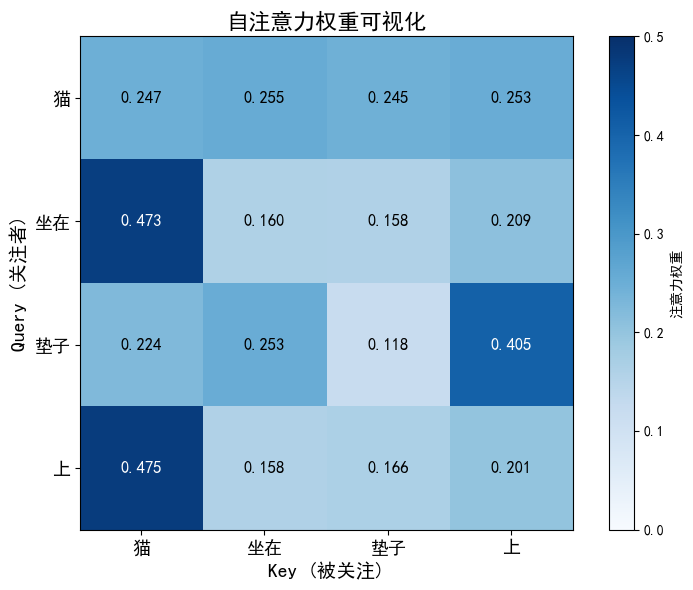

热力图解读:
  - 颜色越深 = 注意力权重越大 = 两个词的关联越强
  - 每行的和为 1（softmax 保证）
  - 对角线通常权重较大（每个词关注自己）
  - 非对角线表示词与词之间的语义关联


In [7]:
import matplotlib.pyplot as plt
# 添加常见中文字体以支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'STSong', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# ============================================
# 可视化注意力热力图
# ============================================

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

im = ax.imshow(attn_weights, cmap='Blues', vmin=0, vmax=0.5)
ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words, fontsize=13)
ax.set_yticklabels(words, fontsize=13)

# 在每个格子中标注数值
for i in range(len(words)):
    for j in range(len(words)):
        color = 'white' if attn_weights[i,j] > 0.3 else 'black'
        ax.text(j, i, f'{attn_weights[i,j]:.3f}', ha='center', va='center',
                fontsize=12, color=color)

ax.set_xlabel('Key (被关注)', fontsize=14)
ax.set_ylabel('Query (关注者)', fontsize=14)
ax.set_title('自注意力权重可视化', fontsize=16, fontweight='bold')
plt.colorbar(im, ax=ax, label='注意力权重')
plt.tight_layout()
plt.show()

print("热力图解读:")
print("  - 颜色越深 = 注意力权重越大 = 两个词的关联越强")
print("  - 每行的和为 1（softmax 保证）")
print("  - 对角线通常权重较大（每个词关注自己）")
print("  - 非对角线表示词与词之间的语义关联")

### 7.4 多头注意力与模型对比示意

In [8]:
# ============================================
# 模型架构对比示意
# ============================================

print("=" * 65)
print("主流大语言模型架构对比")
print("=" * 65)
print()
print("┌─────────────────────────────────────────────────────────────┐")
print("│  GPT 系列 (Decoder-Only)                                   │")
print("│  ┌───────────┐  ┌───────────┐       ┌───────────┐           │")
print("│  │Masked Self │→│Masked Self │→ ...→│ Linear+   │→ Output   │")
print("│  │ Attention  │  │ Attention │       │ Softmax   │           │")
print("│  └───────────┘  └───────────┘       └───────────┘           │")
print("│  特点: 只能看到之前的词(因果), 擅长文本生成                  │")
print("│  代表: GPT-4, ChatGPT, LLaMA, Qwen, DeepSeek              │")
print("├─────────────────────────────────────────────────────────────┤")
print("│  BERT 系列 (Encoder-Only)                                   │")
print("│  ┌───────────┐  ┌───────────┐  ┌───────────┐              │")
print("│  │  Self     │→│  Self     │→ ...→│ [CLS] 向量│→ 下游任务  │")
print("│  │ Attention │  │ Attention │       │ 分类头     │           │")
print("│  └───────────┘  └───────────┘       └───────────┘              │")
print("│  特点: 双向注意力, 擅长理解任务                              │")
print("│  代表: BERT, RoBERTa, DeBERTa                              │")
print("├─────────────────────────────────────────────────────────────┤")
print("│  T5 系列 (Encoder-Decoder)                                  │")
print("│  ┌───────────┐  ┌───────────┐       ┌───────────────┐    │")
print("│  │  Encoder   │  │  Encoder   │       │   Decoder     │    │")
print("│  │  Self-Attn │→│  Self-Attn │───→──→│ Self+Cross-Attn│→Out│")
print("│  └───────────┘  └───────────┘       └───────────────┘    │")
print("│  特点: 编码-解码架构, 擅长 Seq2Seq 任务                    │")
print("│  代表: T5, BART, mBART                                      │")
print("└─────────────────────────────────────────────────────────────┘")
print()
print("训练方式对比:")
print("  GPT:  自回归 → 预测下一个词")
print("  BERT: 掩码语言模型 → 预测被遮盖的词")
print("  T5:   Span Corruption → 预测被遮盖的文本片段")

主流大语言模型架构对比

┌─────────────────────────────────────────────────────────────┐
│  GPT 系列 (Decoder-Only)                                   │
│  ┌───────────┐  ┌───────────┐       ┌───────────┐           │
│  │Masked Self │→│Masked Self │→ ...→│ Linear+   │→ Output   │
│  │ Attention  │  │ Attention │       │ Softmax   │           │
│  └───────────┘  └───────────┘       └───────────┘           │
│  特点: 只能看到之前的词(因果), 擅长文本生成                  │
│  代表: GPT-4, ChatGPT, LLaMA, Qwen, DeepSeek              │
├─────────────────────────────────────────────────────────────┤
│  BERT 系列 (Encoder-Only)                                   │
│  ┌───────────┐  ┌───────────┐  ┌───────────┐              │
│  │  Self     │→│  Self     │→ ...→│ [CLS] 向量│→ 下游任务  │
│  │ Attention │  │ Attention │       │ 分类头     │           │
│  └───────────┘  └───────────┘       └───────────┘              │
│  特点: 双向注意力, 擅长理解任务                              │
│  代表: BERT, RoBERTa, DeBERTa                              │
├──────────

---

## 📝 练习题

### 题目 1：核心概念

**Q1.** 请写出 Transformer 自注意力机制的完整公式，并解释 $Q, K, V$ 的含义。

<details>
<summary>点击查看答案</summary>

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- **Q（Query）**：查询向量，表示当前词想"询问"什么信息
- **K（Key）**：键向量，表示每个词能"提供"什么信息
- **V（Value）**：值向量，表示每个词的"实际内容"
- $d_k$：Key 向量的维度，用于缩放防止梯度消失

$QK^T$ 计算查询与每个键的相似度（点积），$\sqrt{d_k}$ 缩放使梯度稳定，softmax 归一化为权重，最后加权求和 Value。

</details>

### 题目 2：模型对比

**Q2.** 请从架构类型、训练方式、擅长任务三个维度对比 GPT 和 BERT。

<details>
<summary>点击查看答案</summary>

| 维度 | GPT | BERT |
|------|-----|------|
| 架构类型 | Decoder-only | Encoder-only |
| 训练方式 | 自回归（预测下一个词） | 掩码语言模型（MLM） |
| 注意力 | 因果注意力（只能看前面的词） | 双向注意力（能看到所有词） |
| 擅长任务 | 文本生成、对话 | 文本分类、NER、理解任务 |

</details>

### 题目 3：预训练-微调

**Q3.** 什么是预训练-微调范式？为什么不能直接用预训练模型做所有任务？

<details>
<summary>点击查看答案</summary>

**预训练-微调范式**：
1. **预训练**：在海量无标注数据上训练，学习通用语言知识
2. **微调**：在特定任务的标注数据上继续训练，适配具体任务

**为什么需要微调**：
- 预训练模型学习的是通用知识，不一定适合所有特定任务
- 不同任务的输入输出格式不同（如分类 vs 生成）
- 微调可以在少量数据下快速适配，成本远低于从头训练

</details>

### 题目 4：LoRA

**Q4.** LoRA 的核心思想是什么？为什么它比全参数微调更高效？

<details>
<summary>点击查看答案</summary>

LoRA 的核心思想是将权重更新分解为**低秩矩阵**：

$$\Delta W = BA$$

其中 $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times k}$，$r \ll \min(d, k)$。

**高效的原因**：
- 参数量：从 $d \times k$ 减少到 $d \times r + r \times k = r(d+k)$
- 当 $d=k=4096, r=16$ 时，参数减少约 256 倍
- 训练速度更快，显存占用更小
- 原始权重 $W_0$ 冻结，不需要计算其梯度

</details>

### 题目 5：竞赛真题风格

**Q5.** 关于 Transformer 的自注意力机制，以下说法正确的是（ ）

A. $QK^T$ 中的 $Q$ 和 $K$ 维度可以不同
B. 缩放因子 $\sqrt{d_k}$ 可以省略，不影响结果
C. 多头注意力中，每个头使用不同的 $W^Q, W^K, W^V$ 投影矩阵
D. 自注意力只能捕捉相邻词之间的关系

<details>
<summary>点击查看答案</summary>

**答案：C**

- A 错误：$Q$ 和 $K$ 的维度必须相同（都是 $d_k$），否则无法做矩阵乘法 $QK^T$
- B 错误：当 $d_k$ 较大时，点积值很大，softmax 会使梯度趋近于 0，因此缩放因子不可省略
- C 正确：每个注意力头使用不同的投影矩阵，学习不同的注意力模式
- D 错误：自注意力的核心优势就是能捕捉**任意距离**的词之间的关系（全局注意力）

</details>

### 题目 6：综合思考

**Q6.** 为什么 Transformer 取代了 RNN 成为大语言模型的标准架构？请至少给出三个理由。

<details>
<summary>点击查看答案</summary>

1. **并行计算**：Transformer 的自注意力可以并行计算所有位置的关系，而 RNN 必须串行计算，训练效率差
2. **长距离依赖**：自注意力直接计算任意两个位置的关系，不受距离限制；RNN 的信息传递需要经过多步，长距离信息容易丢失
3. **梯度传播**：Transformer 中信息从一个位置到另一个位置只需一步（通过注意力权重），梯度更稳定；RNN 的梯度需要经过时间步反向传播，容易消失
4. **可扩展性**：Transformer 更容易扩展到大规模数据和模型参数

</details>
